# **Week 12 -- Solutions: Categorical Data Analysis via Chi-squared Tests**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```


This week, we will explore how to perform chi-squared tests in R to check for associations between categorical variables and to assess goodness of fit.

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Datasets and Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/edelweiss611428/MXB107-Notebooks.git")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr



**Do not modify the following**

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🥇.


## **Chi-squared Tests in R**




R provides the `chisq.test()` function for performing **chi-squared tests**.  
It can be used for two main purposes:
- **Goodness-of-fit tests** – to check whether observed frequencies match expected probabilities.  
- **Tests of independence** – to determine whether two categorical variables are associated.


**Basic usage:**
```r
chisq.test(x,
           y = NULL,
           p = NULL,
           rescale.p = FALSE)


**Arguments:**
- `x`: a numeric vector of observed counts (for goodness-of-fit) or a matrix/table of counts (for independence tests)
- `y`: an optional second vector of counts, used when testing the independence between two categorical variables
- `p`: a vector of expected probabilities for goodness-of-fit tests; must be the same length as x and sum to 1
- `rescale.p`: logical; if TRUE, rescales p to sum to 1 if it does not already


**Details:**
- For a **goodness-of-fit test**, `x` is a vector of observed frequencies, and `p` gives the expected proportions.  
- For a **test of independence**, `x` is a contingency table (e.g., created with `table()` for instance), and the test checks for association between row and column variables are independent.  
- The function returns an object of class `"htest"`, containing the test statistic, degrees of freedom, and p-value.


### **Chi-squared Tests of Independence**




#### **`Titanic` Example**

To demonstrate the chi-squared for tests of independence, we return to the `Titanic` example from a previous week, which is derived from the well-known `Titanic` dataset, containing information on 2,201 passengers aboard the Titanic, including their:

- Passenger class (`class`)
- Sex (`sex`)
- Age group (`age_status`, i.e., adult or child)
- Survival status (`survived`)

In [4]:
titanic = read.csv("./datasets/titanic.csv", stringsAsFactors = T)
head(titanic)

,Class,Sex,Age,Survived
,<fct>,<fct>,<fct>,<fct>
1,3rd,Male,Child,No
2,3rd,Male,Child,No
3,3rd,Male,Child,No
4,3rd,Male,Child,No
5,3rd,Male,Child,No
6,3rd,Male,Child,No


We are interested in testing whether or not there is an association between passenger class and survival. This test can be formalised as follows:

- **Null hypothesis (H₀):**
$$
P(\text{Survival} \mid \text{Class}) = P(\text{Survival})
$$
(Survival is independent of passenger class)

- **Alternative hypothesis (H₁):**
$$
P(\text{Survival} \mid \text{Class}) \neq P(\text{Survival})
$$
(Survival depends on passenger class)

Here is the unnormalised and normalised contingency tables for `Class` and `Survived`.

In [5]:
unnormalised_table = table(titanic$Class, titanic$Survived)
print(unnormalised_table)
normalised_table = prop.table(unnormalised_table, margin = 1)*100 #Normalised by row (i.e., within each class)
print(normalised_table)

      
        No Yes
  1st  122 203
  2nd  167 118
  3rd  528 178
  Crew 673 212
      
             No      Yes
  1st  37.53846 62.46154
  2nd  58.59649 41.40351
  3rd  74.78754 25.21246
  Crew 76.04520 23.95480


Informally, we can see that the survival rate increases as you go from Crew members to 1st class. This aligns with historical accounts, as most crew members (especially those working in lower bunkers) had higher mortality, while passengers in 1st class, located on the upper decks, had easier access to lifeboats.

We can run a chi-squared test of independence to formally assess this.

In [7]:
chisq.test(unnormalised_table)


	Pearson's Chi-squared test

data:  unnormalised_table
X-squared = 190.4, df = 3, p-value < 2.2e-16


Or equivalently,

In [8]:
chisq.test(titanic$Class, titanic$Survived)


	Pearson's Chi-squared test

data:  titanic$Class and titanic$Survived
X-squared = 190.4, df = 3, p-value < 2.2e-16


Here, we don't need to create a contingency table as R will automatically do that.

From the output, the number of degrees of freedom is 3, which is:

$$\text{(#Categories in Class - 1)} \times \text{(#Categories in Survived - 1)} = (4-1)\times(2-1) = 3$$

The p-value is extremely small. There is overwhelming evidence against the null. This suggests that there is very strong evidence of an association between `Survived` and `Class`, as we expected.

**Exercise**: Do the calculations manually and compute the p-value using the cdf of the chi-square distribution with appropriate degrees of freedom.  Verify you get the same result as with the in-built function.

<details>
<summary>▶️ Click to show the solution</summary>

```r
row_totals <- rowSums(unnormalised_table)
col_totals <- colSums(unnormalised_table)
grand_total <- sum(unnormalised_table)

# expected counts
expected_counts <- outer(row_totals, col_totals) / grand_total

expected_counts

# all expected counts > 5 so ok for chi-square approximation
test_stat = sum((unnormalised_table - expected_counts)^2/expected_counts)
test_stat

# compute pvalue from the cdf of chi-square distribution with 3 degrees of freedom (we want the area in the upper tail)
pval = pchisq(test_stat, 3, lower.tail = FALSE)
pval

# we get an extremely small pvalue as before
```
</details>

### **Chi-squared Goodness-of-Fit Test**



#### **Benford's Law Example**


**Question:**  

Benford's Law states that in many naturally occurring datasets, smaller digits appear as the leading digit more frequently than larger digits, with the probability of the first digit $d$ given by:

$$
P(D = d) = \log_{10}\left(1 + \frac{1}{d}\right), \quad d = 1, 2, \dots, 9
$$

![Benford Law](https://upload.wikimedia.org/wikipedia/commons/8/82/Benford-physical.svg)


This has been utilised in various applications, e.g., fraud detection, where Benford's Law provides a **heuristic** to check for evidence of fraud in accounting or financial datasets.

As an example, we collect financial data from Jane's accounting records. We will evaluate whether there is any evidence of fraud by testing whether the data follow Benford's Law.


In [17]:
Jane = read.csv("./datasets/Jane.csv")
Jane = Jane$x    # pull out relevant column
Jane

[1]  189   48  658  116  178  222   55   50  141  264  160  301  207  256
  [15]   36  292   67   93  134   29  134   96   72   85  516   42  120   13
  [29]   76   90  694   57   62   37  178  471   45   97  582   75  295  219
  [43]   40  501  329   91   60  100  335   84   23  129  321   47  117   44
  [57]  167  130  143   80   73  355  165  123    6   41  318   99   44   96
  [71]  102   90  244  679  399  516  107  345   56  129 1320  147  109   83
  [85]  321 1219  224  114 1181   68  460   97   53  502   25  109  151   95
  [99]   29   78   31 1016   23   18  298  368  122  121  306  601   30  547
 [113]  181  106  526  380  533  111  323  199   88  860  174  141  252  219
 [127]   73  141 2011  138  110  309  222   87   50  346  167  240  111   28
 [141]  159 1621   34   55   39  103  591  127  115   41  158  418 1423  553
 [155]   62   90  272  147  195   40   97   59   59   72   98  148  280   89
 [169]   63  747  401  298  812   56 1151  506  202  277  158  133   31  312
 [183] 1264 1200  176  133  178  467  650  223  452  144  244  486 5651  141
 [197]   76  232   99  280  209  553   57   44  712  186   59   51   85  268
 [211]   88  568  189  181  146  110  126  472   39  440  105  309  140   39
 [225]  210   78  457   65   25   63   84   65  117   82   98  206   46  317
 [239]  148  143   19  110   85  346  596  508   49   67  136   51   30  327
 [253]  159  274   45  106   46   65  187   66   55   40   35   63  815   77
 [267]   49   36  128  100  191  112  353  305  427  189  452  137  377  127
 [281]   75   44   73   70  264  141   79   60  674  117   43   97  163  341
 [295]  136  166   52  329  164  310  697  177  112   69   83   59  215   34
 [309]   26   76  439  168   91  290  104  132  160  441  541  535  395  206
 [323]  972 1145  560  119   52  180   85  195   86  373 1325  389  312  154
 [337] 1314  137  588  717  174    6  107  234   40   41  367    9  187  113
 [351]   77  158  157  190  168   87  192  594  289  663  113  266  246   71
 [365]   66  963   65  384  114   49   32   44   21   61  393   83  843  125
 [379]   58  112   82   95  158  161  317  255  323  169   66  233  224   99
 [393]  101  444  567  166  100  775   43   60  347   59  363   58  254  124
 [407]  362  561  134  275   25  114   44  182  146  117  123  384  127  948
 [421]   22  213 1230   48   67  100  163  117   94 1019  168  442    8  459
 [435]  551   92  119  787  155  419  267  127  111   36   17  145  194   90
 [449]  279  239  106  156  542  203  331  241  833  164   55   94  188  113
 [463]  125  289   68   22 1118  229  424  109  163   17  212  237   60   87
 [477]  569  237  115  215   39  479   22   54  292  470   26  271  209  143
 [491]   79   63  173  496   33   52  763   44   11  151  209  150   62  209
 [505]  124  373  201  297  206  223  317   15  249   39  213  553   95   66
 [519]  136  724  164  172   86   88  129   30  510  106   20  146  117   25
 [533] 1153   49   38  233  417  122  186   49  386  203  164  314  403   71
 [547]  240   55 1380  234  143   91  119   49  158  266   89   66   29  262
 [561]  207  120   86  192   38   34   35  103  327  303   84  613   47   91
 [575]   71  174   26  485  496  395  137  472  241  387  177  199   18   87
 [589]  409  164   44   57   85 1239  124   78   18   22  504   63  751  107
 [603]   14 1330   50   89  163  132   33   33  599   73  340  819   68   73
 [617]   20  992   70  102   38  312  743  186   99   28  659  296  142  495
 [631]  544   93   44  389  297   90 3477   12  147  463  654  394  172  327
 [645]  259  144   62  501  104  111  191  150   21   97  274  508   42   77
 [659]   13  402  149  327   85  184  394  117  347  285   30  202   12  112
 [673]   85  356  199   82  127  178   54   75   43   32   88  146   31  237
 [687]   76  203  171  102   21   30   12  579  103 1029   35  653  435   70
 [701]  303  265  128  670  112 1127   45  551   88  212  138  130  136  372
 [715]  153  578  166  177  141   97  183  401  335  402  839  212  173  701

We first need to extract first digits of numbers in `Jane`.

In [18]:
first_digits = as.numeric(substr(as.character(Jane), 1, 1))
first_digits

[1] 1 4 6 1 1 2 5 5 1 2 1 3 2 2 3 2 6 9 1 2 1 9 7 8 5 4 1 1 7 9 6 5 6 3 1 4 4
  [38] 9 5 7 2 2 4 5 3 9 6 1 3 8 2 1 3 4 1 4 1 1 1 8 7 3 1 1 6 4 3 9 4 9 1 9 2 6
  [75] 3 5 1 3 5 1 1 1 1 8 3 1 2 1 1 6 4 9 5 5 2 1 1 9 2 7 3 1 2 1 2 3 1 1 3 6 3
 [112] 5 1 1 5 3 5 1 3 1 8 8 1 1 2 2 7 1 2 1 1 3 2 8 5 3 1 2 1 2 1 1 3 5 3 1 5 1
 [149] 1 4 1 4 1 5 6 9 2 1 1 4 9 5 5 7 9 1 2 8 6 7 4 2 8 5 1 5 2 2 1 1 3 3 1 1 1
 [186] 1 1 4 6 2 4 1 2 4 5 1 7 2 9 2 2 5 5 4 7 1 5 5 8 2 8 5 1 1 1 1 1 4 3 4 1 3
 [223] 1 3 2 7 4 6 2 6 8 6 1 8 9 2 4 3 1 1 1 1 8 3 5 5 4 6 1 5 3 3 1 2 4 1 4 6 1
 [260] 6 5 4 3 6 8 7 4 3 1 1 1 1 3 3 4 1 4 1 3 1 7 4 7 7 2 1 7 6 6 1 4 9 1 3 1 1
 [297] 5 3 1 3 6 1 1 6 8 5 2 3 2 7 4 1 9 2 1 1 1 4 5 5 3 2 9 1 5 1 5 1 8 1 8 3 1
 [334] 3 3 1 1 1 5 7 1 6 1 2 4 4 3 9 1 1 7 1 1 1 1 8 1 5 2 6 1 2 2 7 6 9 6 3 1 4
 [371] 3 4 2 6 3 8 8 1 5 1 8 9 1 1 3 2 3 1 6 2 2 9 1 4 5 1 1 7 4 6 3 5 3 5 2 1 3
 [408] 5 1 2 2 1 4 1 1 1 1 3 1 9 2 2 1 4 6 1 1 1 9 1 1 4 8 4 5 9 1 7 1 4 2 1 1 3
 [445] 1 1 1 9 2 2 1 1 5 2 3 2 8 1 5 9 1 1 1 2 6 2 1 2 4 1 1 1 2 2 6 8 5 2 1 2 3
 [482] 4 2 5 2 4 2 2 2 1 7 6 1 4 3 5 7 4 1 1 2 1 6 2 1 3 2 2 2 2 3 1 2 3 2 5 9 6
 [519] 1 7 1 1 8 8 1 3 5 1 2 1 1 2 1 4 3 2 4 1 1 4 3 2 1 3 4 7 2 5 1 2 1 9 1 4 1
 [556] 2 8 6 2 2 2 1 8 1 3 3 3 1 3 3 8 6 4 9 7 1 2 4 4 3 1 4 2 3 1 1 1 8 4 1 4 5
 [593] 8 1 1 7 1 2 5 6 7 1 1 1 5 8 1 1 3 3 5 7 3 8 6 7 2 9 7 1 3 3 7 1 9 2 6 2 1
 [630] 4 5 9 4 3 2 9 3 1 1 4 6 3 1 3 2 1 6 5 1 1 1 1 2 9 2 5 4 7 1 4 1 3 8 1 3 1
 [667] 3 2 3 2 1 1 8 3 1 8 1 1 5 7 4 3 8 1 3 2 7 2 1 1 2 3 1 5 1 1 3 6 4 7 3 2 1
 [704] 6 1 1 4 5 8 2 1 1 1 3 1 5 1 1 1 9 1 4 3 4 8 2 1 7 1 5 6 7 3 6 8 4 1 9 2 8
 [741] 2 5 4 3 3 4 2 2 6 2 1 2 3 3 1 3 5 8 8 2 1 1 4 1 1 3 4 1 9 1 9 9 3 1 1 8 4
 [778] 2 1 8 8 7 2 2 1 2 9 4 3 1 4 2 1 6 1 2 1 3 1 3 8 1 4 1 1 1 4 3 3 1 2 1 6 3
 [815] 1 2 5 1 5 1 3 1 1 7 1 1 2 1 6 4 4 1 3 6 1 1 3 1 3 4 8 2 9 2 4 1 3 1 2 1 7
 [852] 1 2 1 2 1 8 3 6 5 1 2 2 3 7 3 2 4 9 6 1 7 2 1 7 6 1 5 2 1 5 3 3 3 3 2 1 1
 [889] 2 7 2 3 2 9 3 1 4 6 4 1 6 2 7 2 1 2 1 4 1 1 1 5 2 1 3 5 7 6 1 6 2 6 7 2 1
 [926] 9 9 2 5 3 7 9 1 1 7 5 1 2 9 4 1 2 7 2 4 9 1 8 3 3 7 3 8 1 5 1 1 3 2 1 5 1
 [963] 1 9 5 1 4 2 1 3 5 9 9 1 7 7 1 3 2 6 1 1 2 5 2 5 1 8 1 7 5 1 4 1 1 7 8 2 1
[1000] 4

A frequency table can be created to estimate the frequency of each leading digit in the dataset. We can also visualise these frequencies to see whether they closely match Benford's Law.

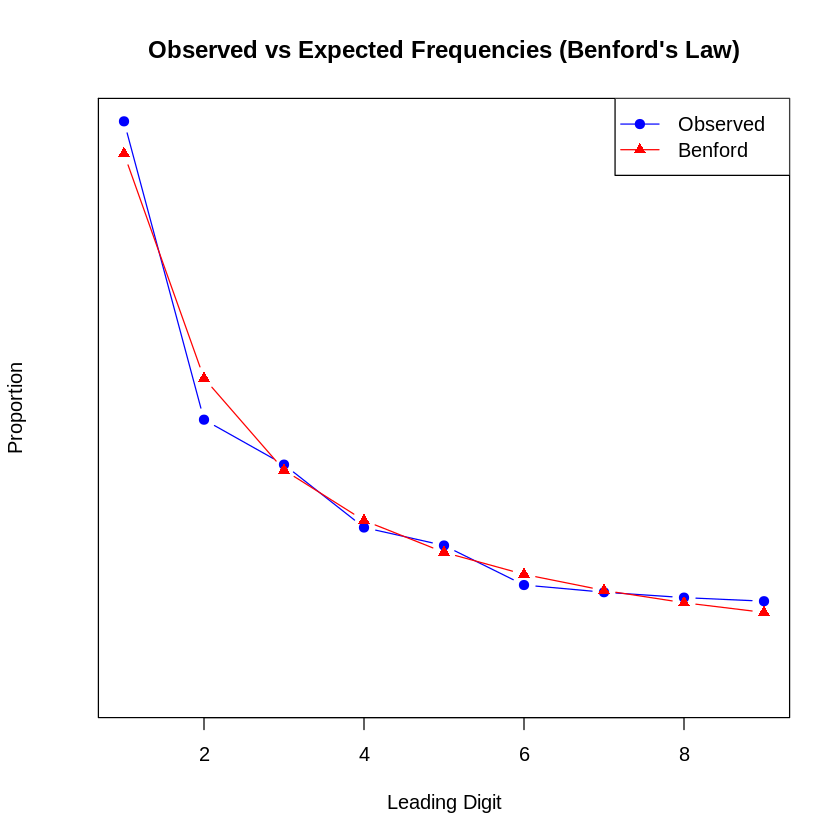

In [19]:
# Observed (relative) frequencies
obs_freq = table(first_digits)/length(first_digits)

# Benford's Law's Predictions
benford_freq = log10(1 + 1 / (1:9))

# Plot observed frequencies
plot(
  1:9, obs_freq,
  type = "b", pch = 19, col = "blue",
  xlab = "Leading Digit",
  ylab = "Proportion",
  ylim = c(0, max(c(obs_freq, benford_freq))),
  main = "Observed vs Expected Frequencies (Benford's Law)"
)

# Add Benford expected frequencies
lines(1:9, benford_freq, type = "b", pch = 17, col = "red")

# Add legend
legend(
  "topright",
  legend = c("Observed", "Benford"),
  col = c("blue", "red"),
  pch = c(19, 17),
  lty = 1
)


The observed frequencies appear to closely match Benford's Law. For a more formal assessment, we can perform a chi-squared test for goodness-of-fit.


- **Null hypothesis (H₀):** The distribution of the leading digits in the dataset follows Benford's Law.  
- **Alternative hypothesis (H₁):** The distribution of the leading digits in the dataset does **not** follow Benford's Law.


In [23]:
obs_counts = table(first_digits)
benford_freq = log10(1 + 1 / (1:9))


chisq.test(x = obs_counts, p = benford_freq)





	Chi-squared test for given probabilities

data:  obs_counts
X-squared = 6.073, df = 8, p-value = 0.6391


Here, the number of degrees of freedom is $8$, which is $9-1$. The p-value is 0.6391, quite larger than any conventional thresholds (e.g., 5%, 1%, or 10%). Therefore, there is no evidence against the hypothesis that the observed frequencies follow Benford's Law.

According to this analysis, Jane's book appears to be consistent with the  distribution implied by Benford's law.

**Exercise**: Do the calculations manually and compute the p-value using the cdf of the chi-square distribution with appropriate degrees of freedom.  Verify you get the same result as with the in-built function.


<details>
<summary>▶️ Click to show the solution</summary>

```r
# we can also do the calculations manually
benford_counts = benford_freq*length(first_digits)
obs_counts
benford_counts

# we can see all expected counts > 5, so chi-square approximation is reasonable

test_stat = sum((obs_counts - benford_counts)^2/benford_counts)
test_stat

pval = pchisq(test_stat, length(benford_counts) - 1, lower.tail = FALSE)
pval

# as we can see, we get the same p-value is with the in-built function
```
</details>

## **Workshop Questions**

### **Question 1**

Given the `titanic` dataset, use an appropriate method to test if there is any association between passenger class (`Class`) and sex (`Sex`).

<details>
<summary>▶️ Click to show the solution</summary>

```r
# We are interested in testing whether or not there is an association between sex and survival. Here, a chi-squared test of independence can be used, which is formalised as follows:
# H_0: Surival is independent of sex     H_1: Survival depends on sex

# we can use the in-built function to perform the test
chisq.test(titanic$Survived, titanic$Sex)

# The p-value is extremely small so there is overwhelming evidence against the null.
# Thus there is overwhelming evidence that survival probabilities depend on sex
```
</details>


**FYI:**

> "Women and children first", known to a lesser extent as the Birkenhead drill, is an unofficial code of conduct and gender role whereby the lives of women and children were to be saved first in a life-threatening situation, typically abandoning ship, when survival resources such as lifeboats were limited. However, it has no basis in maritime law."

> "Notable invocations of the concept include during the 1852 evacuation of the Royal Navy troopship HMS Birkenhead, the 1857 sinking of the ship SS Central America, and most famously during the 1912 sinking of the Titanic."

(From [Women and children first - Wikipedia](https://en.wikipedia.org/wiki/Women_and_children_first)

### **Question 2**

Use a chi-squared goodness-of-fit test to determine whether the distribution of hair colors in the `HairEyeColor` dataset differs from what would be expected under a discrete uniform distribution (e.g., all categories are equally likely).


In [38]:
# code to pull out observed frequencies of hair colour
HairColorFreq = margin.table(HairEyeColor, 1)
HairColorFreq

# write the code to perform hypothesis test

Hair
Black Brown   Red Blond 
  108   286    71   127 

<details>
<summary>▶️ Click to show the solution</summary>

```r
HairColorFreq = margin.table(HairEyeColor, 1)
HairColorFreq

# The null and alternative hypotheses are:
# H_0: Probability of each hair colour is 1/4 (follows a discrete uniform distribution)
# H_1: Probability of each hair colour does not follow a discrete uniform distribution

# we can use in-built function to perform the test
chisq.test(x = HairColorFreq, p = rep(1/4, 4))

# we can see the p-value is extremely small, hence there is overwhelming evidence against the null
# Therefore there is overwhelming evidence that hair colour does not follow a discrete uniform distribution
```
</details>